In [461]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector,DensityMatrix,state_fidelity,partial_trace, Operator
from matplotlib import pyplot as plt
 
# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)

Hamiltonian:

$H=h(X_1+X_2)+J Z_1 Z_2$

Trotter formula:

$e^{-iH t}=(e^{-i h X_1 \Delta t}e^{-i h X_2 \Delta t}e^{-i J Z_1 Z_2 \Delta t})^n,$

where $\Delta t=t/n$.

In [462]:
def tfim_circuit_with_noise_at_end(qc, n, m, J, h, t, p, epsilon):
    # Time increment for each Trotter step
    dt = t / p
    
    # Create a new quantum circuit
    
    # Define the depolarizing error
    depolarizing = depolarizing_error(epsilon, 1)
    two_qubit_depolarizing = depolarizing_error(epsilon, 2)
    
    for step in range(p):
        # Apply the ZZ coupling terms with noise
        for i in range(n,m):
            qc.rzz(2 * J * dt, i, i + 1)
        
        # Apply the transverse field terms with noise
        for i in range(n,m+1):
            qc.rx(2 * h * dt, i)
    qc.append(two_qubit_depolarizing, [n, m])
    
    return qc


In [472]:
# Example usage
n = 2
m = 3
J = 1.0  # coupling strength
h = 1.0  # transverse field strength
t = 1.0  # total time for evolution
p = 10  # number of Trotter steps
epsilon = 0.1  # error rate for depolarizing channel

qc = QuantumCircuit(5)
circuit = tfim_circuit_with_noise_at_end(qc, n, m,J, h, t, p, epsilon)
print(circuit)

                                                                              »
q_0: ─────────────────────────────────────────────────────────────────────────»
                                                                              »
q_1: ─────────────────────────────────────────────────────────────────────────»
               ┌─────────┐          ┌─────────┐          ┌─────────┐          »
q_2: ─■────────┤ Rx(0.2) ├─■────────┤ Rx(0.2) ├─■────────┤ Rx(0.2) ├─■────────»
      │ZZ(0.2) ├─────────┤ │ZZ(0.2) ├─────────┤ │ZZ(0.2) ├─────────┤ │ZZ(0.2) »
q_3: ─■────────┤ Rx(0.2) ├─■────────┤ Rx(0.2) ├─■────────┤ Rx(0.2) ├─■────────»
               └─────────┘          └─────────┘          └─────────┘          »
q_4: ─────────────────────────────────────────────────────────────────────────»
                                                                              »
«                                                                    »
«q_0: ───────────────────────────────────────────

In [473]:
# Dimension of the Hilbert space
dim = 2 ** 2

# Create the identity matrix
identity_matrix = np.eye(dim)

# Create the maximally mixed state as a density matrix
maximally_mixed_state = DensityMatrix(identity_matrix / dim)


# Define the |0><0| projection matrix for a single qubit
P0 = np.array([[1, 0],
               [0, 0]])
P1 = np.array([[0, 0],
               [0, 1]])

# Define the 2x2 identity matrix
I = np.eye(2)

# Create the 5-qubit projection operator using tensor products
projection_operator0 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0))
projection_operator1 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1))

# Print the matrix representation of the operator
# print("Projection Operator for q0 in |0> and others unaffected:")
# print(projection_operator.data)


# Create a Quantum Circuit acting on a quantum register of five qubits
qc = QuantumCircuit(5)

qc=tfim_circuit_with_noise_at_end(qc, 1, 2,J, h, t, p, epsilon)
qc=tfim_circuit_with_noise_at_end(qc, 3, 4,J, h, t, p, epsilon)

# Apply the Hadamard gate to the first qubit
qc.h(0)

# Apply the first CSWAP gate controlled by q0, targeting q1 and q3
qc.cswap(0, 1, 3)

# Apply the second CSWAP gate controlled by q0, targeting q2 and q4
qc.cswap(0, 2, 4)

# Apply the second Hadamard gate to the first qubit
qc.h(0)

state = DensityMatrix(qc)

# Trace out all qubits except q0 to get the reduced density matrix for q0
# reduced_rho_q0 = partial_trace(state, [1, 2, 3, 4])

# # Extract probabilities from the reduced density matrix of q0
# prob_0 = reduced_rho_q0.data[0, 0].real  # Probability of q0 being in |0>
# prob_1 = reduced_rho_q0.data[1, 1].real  # Probability of q0 being in |1>

projected_rho0=projection_operator0@state@projection_operator0.adjoint()
prob_0=np.trace(projection_operator0@state@projection_operator0)
post_meas_rho0=projected_rho0/prob_0

projected_rho1=projection_operator1@state@projection_operator1.adjoint()
prob_1=np.trace(projection_operator1@state@projection_operator1)
post_meas_rho1=projected_rho1/prob_1

# Trace out qubits q0, q3, and q4
reduced_rho = partial_trace(DensityMatrix(post_meas_rho0), [0, 1, 2])

reduced_rho1 = partial_trace(state, [0, 1, 2])
reduced_rho2 = partial_trace(DensityMatrix(projected_rho0+projected_rho1), [0, 1, 2])

purified_rho=prob_0*reduced_rho + prob_1*maximally_mixed_state

# Print the reduced density matrix
# print("Purified Density Matrix of q1 and q2:\n", purified_rho)
# print(qc)
print(prob_0)
print(prob_1)
# print(np.trace(projection_operator0@state@projection_operator0.adjoint()))
# print(np.trace(projection_operator1@state@projection_operator1.adjoint()))
# print(maximally_mixed_state)
# print(reduced_rho_q0)
print(reduced_rho)
print(reduced_rho1)
print(reduced_rho2)

(0.9287499999999946-3.4900467932308404e-17j)
(0.07124999999999954-2.6248534595874077e-17j)
DensityMatrix([[ 0.3495356 -1.89359766e-17j,  0.199085  +7.44450402e-03j,
                 0.199085  +7.44450402e-03j, -0.11821719+3.33370928e-01j],
               [ 0.199085  -7.44450402e-03j,  0.13201261+1.83651719e-17j,
                 0.11821719-1.27137238e-17j, -0.06270768+2.00301381e-01j],
               [ 0.199085  -7.44450402e-03j,  0.11821719+2.29073518e-17j,
                 0.13201261-1.00162657e-18j, -0.06270768+2.00301381e-01j],
               [-0.11821719-3.33370928e-01j, -0.06270768-2.00301381e-01j,
                -0.06270768-2.00301381e-01j,  0.38643918+1.57243133e-18j]],
              dims=(2, 2))
DensityMatrix([[ 0.34481404-4.13352078e-17j,  0.18964123+7.09136729e-03j,
                 0.18964123+7.09136729e-03j, -0.11260945+3.17557179e-01j],
               [ 0.18964123-7.09136729e-03j,  0.13760945+5.05780313e-18j,
                 0.11260945-1.31947404e-17j, -0.05973309+1.907

In [474]:
# Create a Quantum Circuit acting on a quantum register of 2 qubits
qc = QuantumCircuit(2)

qc=tfim_circuit_with_noise_at_end(qc, 0, 1,J, h, t, p, 0)

pure_state = DensityMatrix(qc)

# Print the density matrix
print("Density Matrix with no noise:\n", pure_state)


Density Matrix with no noise:
 DensityMatrix([[ 0.35534893-5.20417043e-17j,  0.21071247+7.87929699e-03j,
                 0.21071247+7.87929699e-03j, -0.12512161+3.52841310e-01j],
               [ 0.21071247-7.87929699e-03j,  0.12512161+2.86229374e-17j,
                 0.12512161-2.42861287e-17j, -0.0663701 +2.11999895e-01j],
               [ 0.21071247-7.87929699e-03j,  0.12512161+3.29597460e-17j,
                 0.12512161-1.73472348e-17j, -0.0663701 +2.11999895e-01j],
               [-0.12512161-3.52841310e-01j, -0.0663701 -2.11999895e-01j,
                -0.0663701 -2.11999895e-01j,  0.39440785+1.99493200e-17j]],
              dims=(2, 2))


In [475]:
print(state_fidelity(reduced_rho, pure_state))
print(state_fidelity(purified_rho, pure_state))

0.958613734135591
0.9081250087103295


In [476]:
def purified_rho_with(epsilon):

    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(5)
    
    qc=tfim_circuit_with_noise_at_end(qc, 1, 2, J, h, t, p, epsilon)
    qc=tfim_circuit_with_noise_at_end(qc, 3, 4, J, h, t, p, epsilon)
    
    # Apply the Hadamard gate to the first qubit
    qc.h(0)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc.cswap(0, 1, 3)
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc.cswap(0, 2, 4)
    
    # Apply the second Hadamard gate to the first qubit
    qc.h(0)
    
    state = DensityMatrix(qc)

    state = DensityMatrix(qc)

    # Trace out all qubits except q0 to get the reduced density matrix for q0
    # reduced_rho_q0 = partial_trace(state, [1, 2, 3, 4])
    
    # # Extract probabilities from the reduced density matrix of q0
    # prob_0 = reduced_rho_q0.data[0, 0].real  # Probability of q0 being in |0>
    # prob_1 = reduced_rho_q0.data[1, 1].real  # Probability of q0 being in |1>
    
    projected_rho0=projection_operator0@state@projection_operator0.adjoint()
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    post_meas_rho0=projected_rho0/prob_0
    
    projected_rho1=projection_operator1@state@projection_operator1.adjoint()
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    post_meas_rho1=projected_rho1/prob_1
    
    # Trace out qubits q0, q3, and q4
    reduced_rho = partial_trace(DensityMatrix(post_meas_rho0), [0, 1, 2])
    
    reduced_rho1 = partial_trace(state, [0, 1, 2])
    reduced_rho2 = partial_trace(DensityMatrix(projected_rho0+projected_rho1), [0, 1, 2])
    
    purified_rho=prob_0*reduced_rho + prob_1*maximally_mixed_state
        

    return purified_rho


In [477]:
def rho_with(epsilon):

    # Create a Quantum Circuit acting on a quantum register of 2 qubits
    qc = QuantumCircuit(2)
    
    qc=tfim_circuit_with_noise_at_end(qc, 0, 1, J, h, t, p, epsilon)
    
    state = DensityMatrix(qc)

    return state
    

In [478]:
list_of_epsilon=[i * 0.01 for i in range(101)]
list_of_purified_fidelity=[]
list_of_fidelity=[]
for i in list_of_epsilon:
    list_of_purified_fidelity.append(state_fidelity(purified_rho_with(i), pure_state))
    list_of_fidelity.append(state_fidelity(rho_with(i), pure_state))

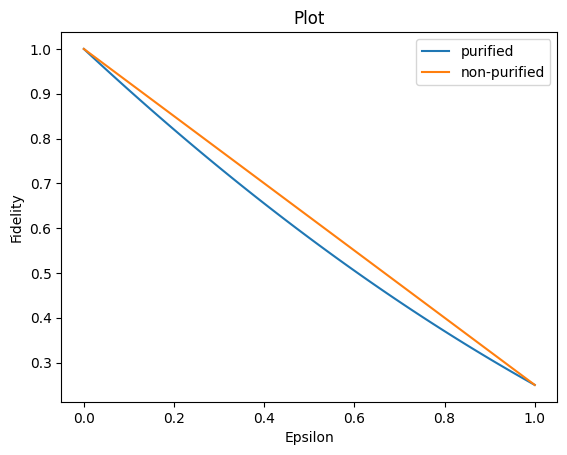

In [479]:
plt.plot(list_of_epsilon,list_of_purified_fidelity,label='purified')
plt.plot(list_of_epsilon,list_of_fidelity,label='non-purified')
plt.title("Plot")
plt.xlabel("Epsilon")
plt.ylabel("Fidelity")
plt.legend()

In [471]:
list_of_fidelity

[0.9999999999999976,
 0.9925000035183517,
 0.9850000049568651,
 0.9775000060477403,
 0.9700000069564868,
 0.9625000077474631,
 0.9550000084537897,
 0.947500009095212,
 0.9400000096846315,
 0.9325000102310409,
 0.9250000107410086,
 0.9175000112195021,
 0.910000011670394,
 0.9025000120967729,
 0.8950000125011439,
 0.8875000128855806,
 0.8800000132518206,
 0.8725000136013306,
 0.8650000139353713,
 0.8575000142550289,
 0.8500000145612511,
 0.8425000148548697,
 0.8350000151366165,
 0.8275000154071442,
 0.8200000156670338,
 0.812500015916807,
 0.8050000161569311,
 0.7975000163878309,
 0.7900000166098919,
 0.7825000168234635,
 0.7750000170288655,
 0.7675000172263902,
 0.7600000174163061,
 0.7525000175988577,
 0.7450000177742739,
 0.737500017942762,
 0.7300000181045175,
 0.7225000182597163,
 0.7150000184085292,
 0.7075000185511054,
 0.7000000186875898,
 0.6925000188181131,
 0.6850000189428008,
 0.6775000190617674,
 0.6700000191751165,
 0.6625000192829497,
 0.6550000193853581,
 0.64750001948242

In [255]:
list_of_purified_fidelity

[0.9999999999999811,
 0.9869590971710934,
 0.9740852547910862,
 0.9613767870607673,
 0.9488320066444085,
 0.9364492261063957,
 0.9242267579801271,
 0.9121629147856751,
 0.9002560090362711,
 0.8885043532412081,
 0.87690625990735,
 0.8654600415399236,
 0.854164010643043,
 0.8430164797200358,
 0.8320157612736128,
 0.8211601678060407,
 0.8104480118192444,
 0.7998776058148703,
 0.7894472622943338,
 0.7791552937588834,
 0.7690000127096078,
 0.7589797316474812,
 0.7490927630733704,
 0.7393374194880412,
 0.7297120133922081,
 0.7202148572865026,
 0.7108442636715022,
 0.7015985450477393,
 0.6924760139156976,
 0.683474982775828,
 0.674593764128539,
 0.665830670474217,
 0.6571840143132148,
 0.6486521081458656,
 0.6402332644724756,
 0.6319257957933306,
 0.6237280146087055,
 0.6156382334188497,
 0.6076547647240026,
 0.5997759210243828,
 0.5920000148202039,
 0.5843253586116613,
 0.5767502648989441,
 0.5692730461822272,
 0.5618920149616757,
 0.554605483737451,
 0.5474117650096977,
 0.5403091712785592,